# Credit Risk & Probability of Default (PD) Modeling | Machine Learning, XAI & Basel III / IFRS 9 Compliance : 

# Credit Risk Assessment & Probability of Default (PD) Modeling

## Introduction

Credit risk refers to the possibility that a borrower may fail to meet their financial obligations and repay a loan according to the agreed terms. Effective credit risk assessment is crucial for banks, financial institutions, and lending organizations, as inaccurate lending decisions can lead to significant financial losses and increased default rates.

With the growth of digital lending and the availability of large volumes of customer data, machine learning techniques have become powerful tools for evaluating borrower risk. By leveraging historical loan and borrower information, predictive models can identify patterns associated with default behavior and support data-driven lending decisions.

This project focuses on developing a Probability of Default (PD) model using machine learning techniques to estimate the likelihood of a borrower defaulting on a loan. The project combines traditional credit risk concepts with modern predictive analytics, feature engineering, and explainable AI techniques to create a robust risk assessment framework.

---

## Business Problem

Financial institutions face the challenge of balancing loan portfolio growth with effective risk management. Approving high-risk borrowers can increase default rates and financial losses, while rejecting creditworthy applicants may reduce profitability and business opportunities.

The objective is to build a predictive system capable of accurately identifying high-risk borrowers before loan approval. Such a system can support underwriting decisions, improve portfolio quality, reduce expected losses, and enhance overall credit risk management practices.

---

## Project Objectives

The primary objectives of this project are:

* Develop a machine learning model to estimate the Probability of Default (PD) for loan applicants.
* Identify the key factors influencing borrower default behavior.
* Compare the performance of Logistic Regression and XGBoost models.
* Generate risk scores that can assist in credit underwriting decisions.
* Segment borrowers into Low, Medium, and High Risk categories based on predicted default probabilities.
* Apply explainable AI techniques to improve model transparency and interpretability.
* Build a scalable framework that can be extended for real-world credit risk applications.

---

## Dataset Overview

The dataset contains information related to borrowers, loan characteristics, employment details, and credit history attributes. These variables provide valuable insights into an individual's repayment capacity and financial behavior.

### Key Features

* Demographic Information

  * Age
  * Home Ownership Status

* Financial Information

  * Annual Income
  * Loan Amount
  * Interest Rate
  * Loan-to-Income Ratio

* Employment Information

  * Employment Length

* Credit History Information

  * Previous Default Records
  * Credit History Length

* Loan Information

  * Loan Intent
  * Loan Grade

### Target Variable

**loan_status**

* 0 → Non-Default
* 1 → Default

The target variable indicates whether a borrower successfully repaid the loan or defaulted.

---

## Methodology

The project follows a structured end-to-end machine learning workflow:

### 1. Data Understanding and Exploration

* Examine dataset structure and feature distributions.
* Assess data quality and identify missing values.
* Analyze class distribution of the target variable.

### 2. Exploratory Data Analysis (EDA)

* Univariate analysis of borrower and loan characteristics.
* Bivariate analysis between risk factors and default status.
* Correlation analysis and risk pattern identification.

### 3. Data Preprocessing

* Handle missing values.
* Treat inconsistent and erroneous records.
* Encode categorical variables.
* Standardize numerical features where necessary.

### 4. Feature Engineering

* Create domain-specific risk indicators.
* Construct loan affordability and creditworthiness metrics.
* Generate borrower risk profiles.

### 5. Model Development

* Build a baseline Logistic Regression model.
* Train an advanced XGBoost classifier.
* Compare model performance across multiple evaluation metrics.

### 6. Model Evaluation

* Accuracy
* Precision
* Recall
* F1 Score
* ROC-AUC Score
* Confusion Matrix Analysis

### 7. Model Explainability

* Analyze feature importance.
* Use SHAP values to interpret model predictions.
* Identify major drivers of borrower default.

### 8. Risk Segmentation

* Convert predicted probabilities into actionable risk categories.
* Classify borrowers into Low, Medium, and High Risk groups.
* Generate insights for lending and portfolio management decisions.


### LIBRARIES :

In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from xgboost import XGBClassifier

import shap

import warnings
warnings.filterwarnings("ignore")

### DATASET : 

In [6]:
df = pd.read_csv("credit_risk_csv.csv")

df.head() 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### DATA DESCRIPTION : 

In [8]:
df.shape

(32581, 12)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [11]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [12]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### TARGET VARIBLE ANALYSIS : 

In [13]:
df["loan_status"].value_counts() 

loan_status
0    25473
1     7108
Name: count, dtype: int64

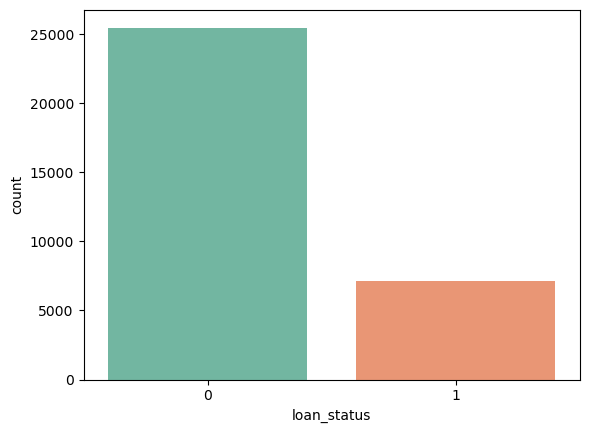

In [16]:
sns.countplot(x="loan_status", data=df, hue="loan_status", palette="Set2", legend=False)
plt.show()

In [17]:
default_rate = df["loan_status"].mean()

print(f"Default Rate = {default_rate:.2%}")

Default Rate = 21.82%


## AVANCED EDA PROCESSING :

#### NUMERICAL FEATURES - Distribution Analysis

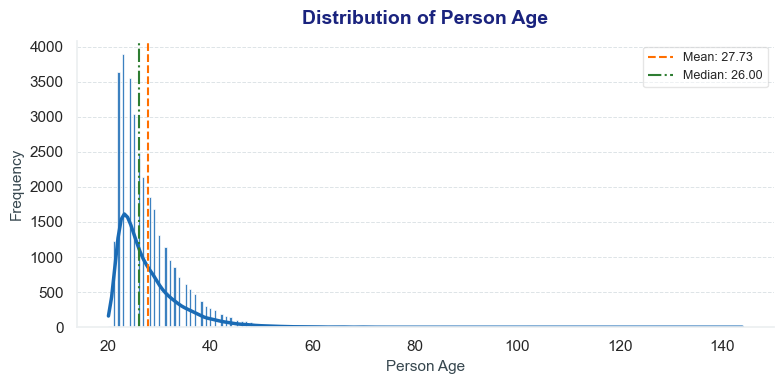

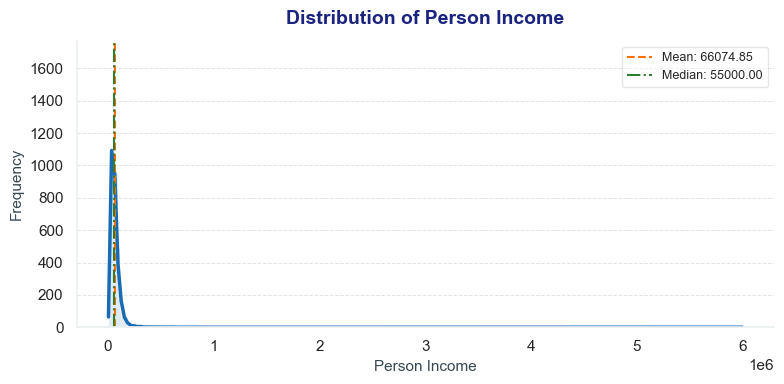

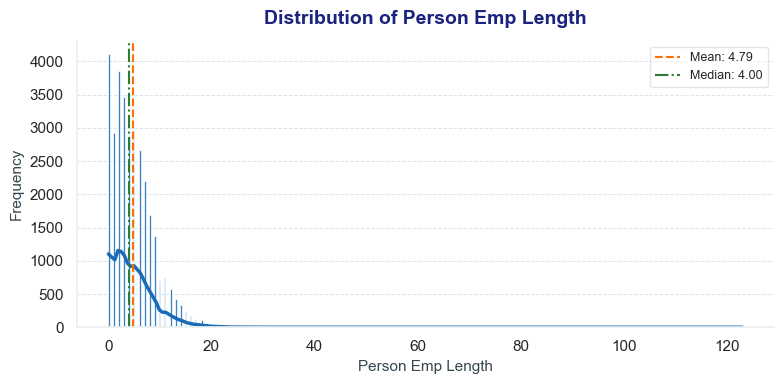

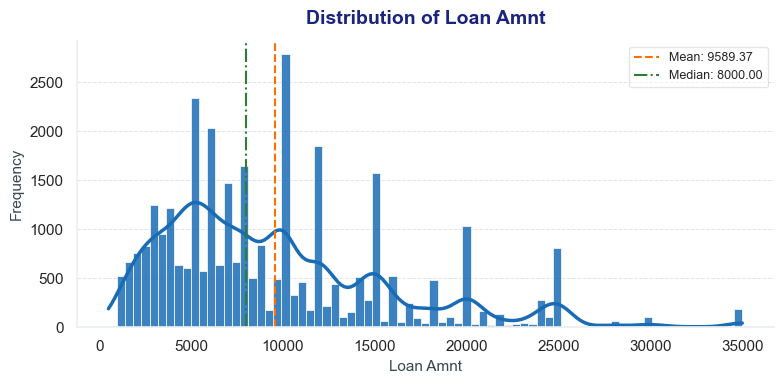

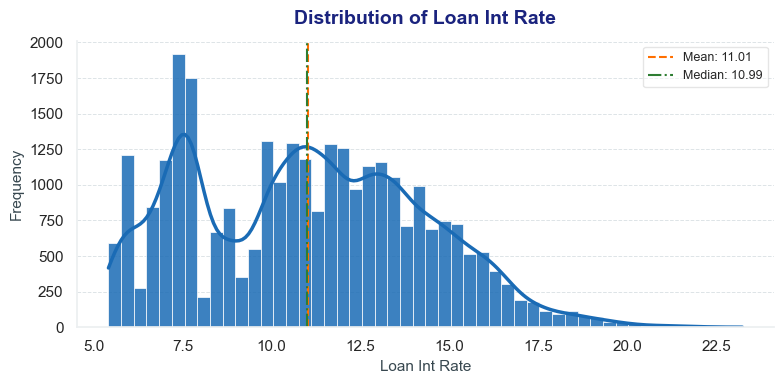

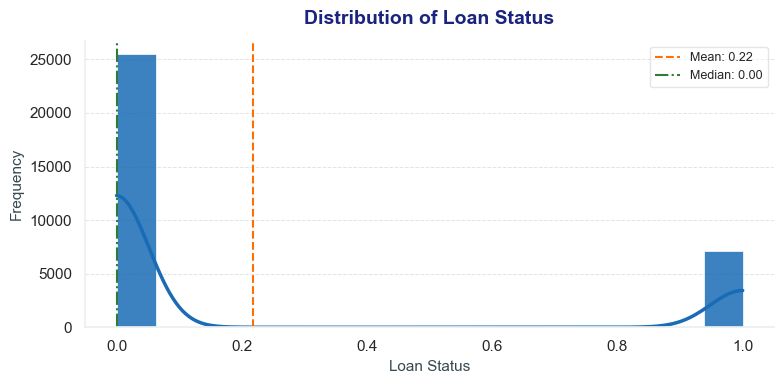

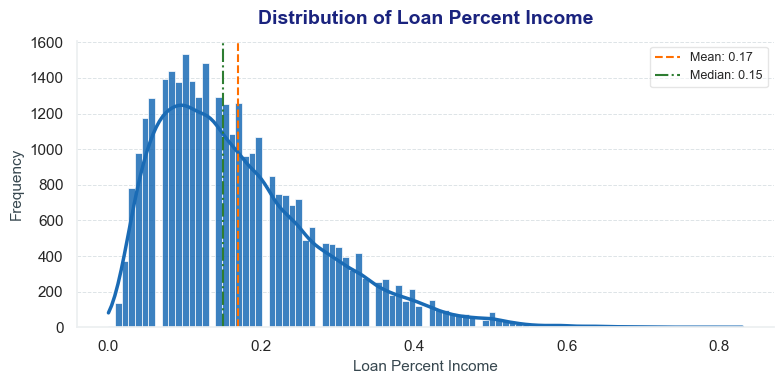

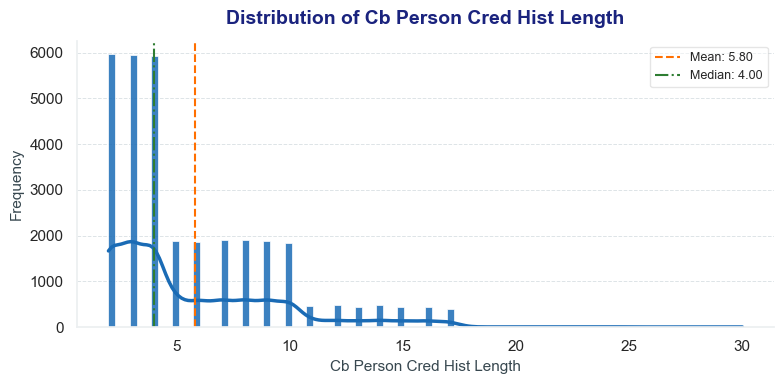

In [21]:
# NUMERICAL FEATURES - Distribution Analysis

sns.set_theme(style="whitegrid", palette="muted")

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    
    sns.histplot(
        df[col],
        kde=True,
        ax=ax,
        color="#1A6BB5",
        edgecolor="white",
        linewidth=0.5,
        alpha=0.85,
        line_kws={"linewidth": 2.5, "color": "#E53935"}
    )
    
    # Professional titles & labels
    ax.set_title(f"Distribution of {col.replace('_', ' ').title()}",
                 fontsize=14, fontweight="bold", pad=12, color="#1A237E")
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=11, color="#37474F")
    ax.set_ylabel("Frequency", fontsize=11, color="#37474F")
    
    # Clean spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#ECEFF1")
    ax.spines["bottom"].set_color("#ECEFF1")
    
    # Subtle grid
    ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7, color="#CFD8DC")
    ax.xaxis.grid(False)
    
    # Mean & Median lines
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color="#FF6F00", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.2f}")
    ax.axvline(median_val, color="#2E7D32", linestyle="-.", linewidth=1.5, label=f"Median: {median_val:.2f}")
    
    ax.legend(fontsize=9, framealpha=0.5)
    plt.tight_layout()
    plt.show()

#### CORRELATION MATRIX - Risk Feature Interdependency Analysis

Text(0.5, -0.02, 'Note: Lower triangle shown. Orange borders indicate strong correlation (|r| ≥ 0.70). High multicollinearity may impact model stability — review for VIF analysis.')

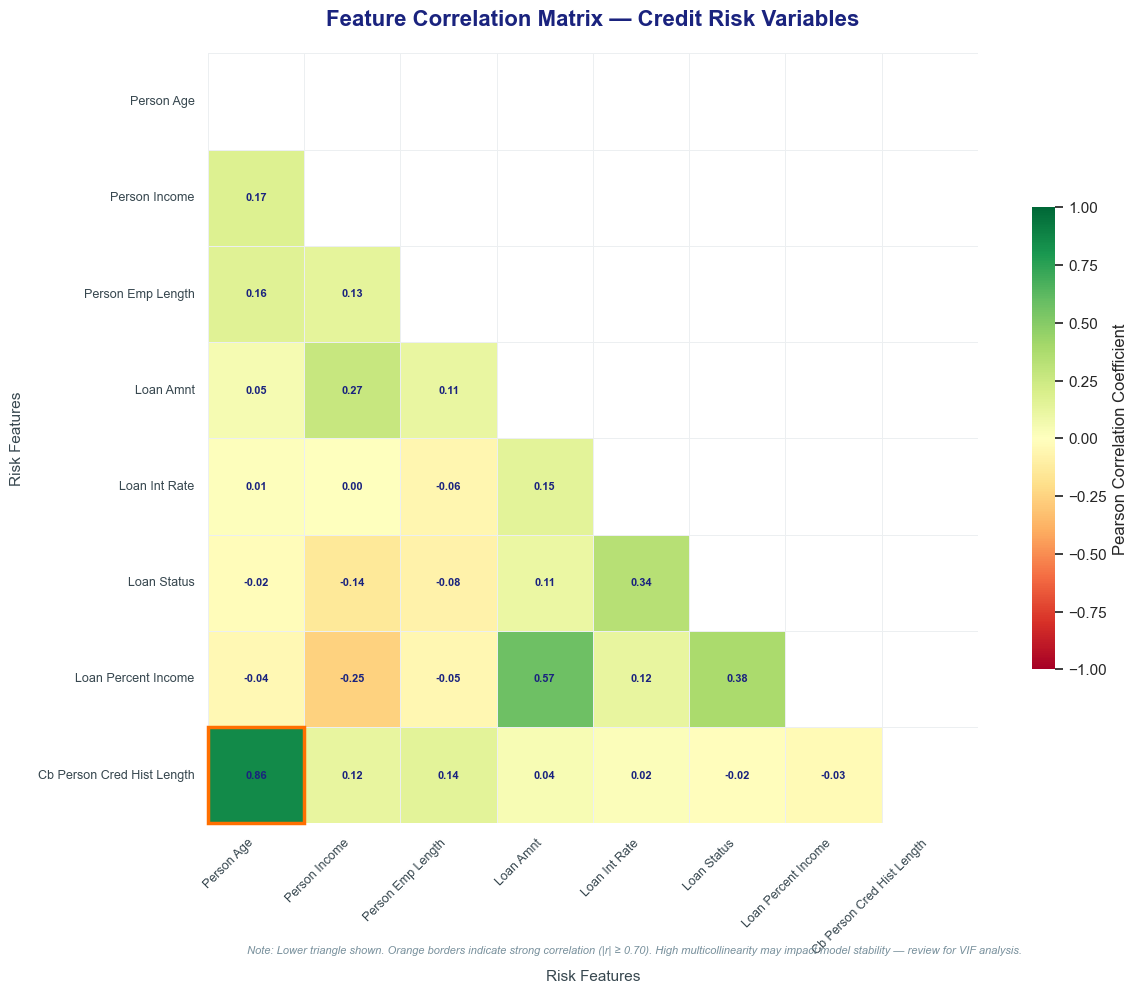

In [24]:
# CORRELATION MATRIX - Risk Feature Interdependency Analysis

sns.set_theme(style="white")

corr_matrix = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="#ECEFF1",
    annot_kws={"size": 8, "weight": "bold", "color": "#1A237E"},
    square=True,
    cbar_kws={
        "shrink": 0.6,
        "label": "Pearson Correlation Coefficient",
        "orientation": "vertical"
    },
    ax=ax
)

# Title
ax.set_title(
    "Feature Correlation Matrix — Credit Risk Variables",
    fontsize=16, fontweight="bold", pad=20, color="#1A237E"
)

# Axis labels
ax.set_xlabel("Risk Features", fontsize=11, color="#37474F", labelpad=10)
ax.set_ylabel("Risk Features", fontsize=11, color="#37474F", labelpad=10)

# Rotate labels cleanly
ax.set_xticklabels(
    [label.get_text().replace("_", " ").title() for label in ax.get_xticklabels()],
    rotation=45, ha="right", fontsize=9, color="#37474F"
)
ax.set_yticklabels(
    [label.get_text().replace("_", " ").title() for label in ax.get_yticklabels()],
    rotation=0, fontsize=9, color="#37474F"
)

# Highlight strong correlations (|r| > 0.7) with a border box
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        if i > j:  # lower triangle only
            val = corr_matrix.iloc[i, j]
            if abs(val) >= 0.7 and i != j:
                ax.add_patch(plt.Rectangle(
                    (j, i), 1, 1,
                    fill=False,
                    edgecolor="#FF6F00",
                    linewidth=2.5,
                    clip_on=False
                ))

# Footnote
fig.text(
    0.5, -0.02,
    "Note: Lower triangle shown. Orange borders indicate strong correlation (|r| ≥ 0.70). "
    + "High multicollinearity may impact model stability — review for VIF analysis.",
    ha="center", fontsize=8, color="#78909C", style="italic"
)

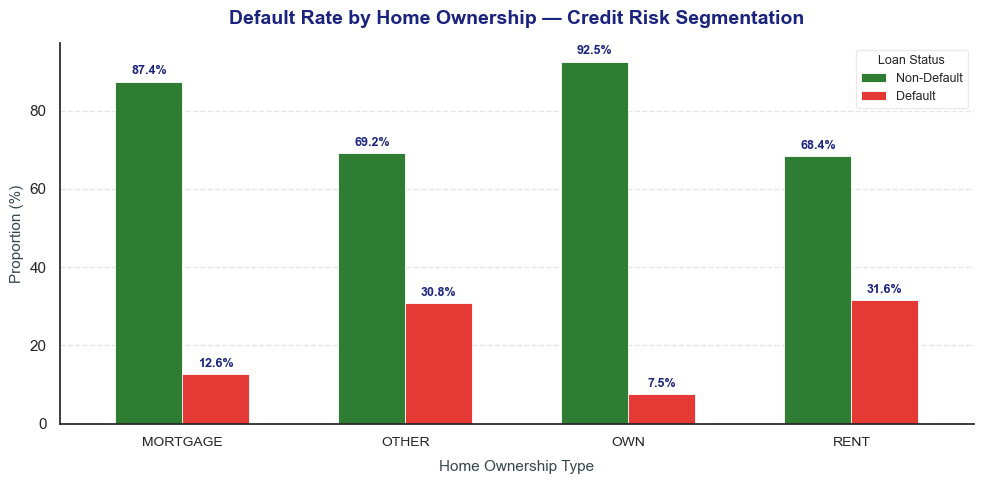

In [25]:
# LOAN DEFAULT RATE BY HOME OWNERSHIP — Risk Segmentation Analysis

crosstab = pd.crosstab(
    df["person_home_ownership"],
    df["loan_status"],
    normalize="index"
).mul(100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))

crosstab.plot(
    kind="bar",
    ax=ax,
    color=["#2E7D32", "#E53935"],
    edgecolor="white",
    linewidth=0.6,
    width=0.6
)

# Labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9,
                 fontweight="bold", color="#1A237E", padding=3)

ax.set_title("Default Rate by Home Ownership — Credit Risk Segmentation",
             fontsize=14, fontweight="bold", color="#1A237E", pad=14)
ax.set_xlabel("Home Ownership Type", fontsize=11, color="#37474F", labelpad=8)
ax.set_ylabel("Proportion (%)", fontsize=11, color="#37474F")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.legend(["Non-Default", "Default"], title="Loan Status",
          fontsize=9, title_fontsize=9, framealpha=0.4)

ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("default_rate_home_ownership.png", dpi=150, bbox_inches="tight")
plt.show()

#### DEFAULT RISK BY HOME OWNERSHIP — Segmentation Analysis

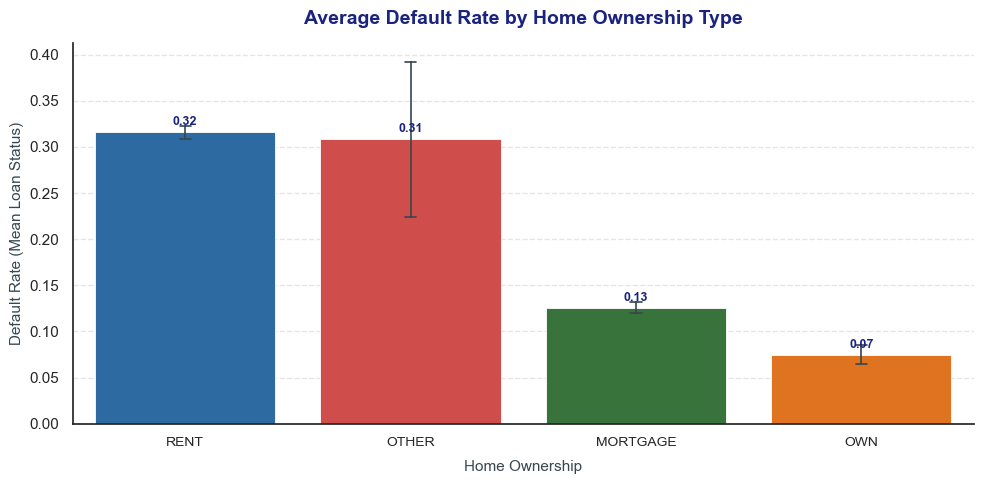

In [26]:
# DEFAULT RISK BY HOME OWNERSHIP — Segmentation Analysis

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x="person_home_ownership",
    y="loan_status",
    data=df,
    palette=["#1A6BB5", "#E53935", "#2E7D32", "#FF6F00"],
    edgecolor="white",
    linewidth=0.6,
    capsize=0.05,
    err_kws={"linewidth": 1.2, "color": "#37474F"},
    order=df.groupby("person_home_ownership")["loan_status"]
           .mean().sort_values(ascending=False).index,
    ax=ax
)

# Bar value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9,
                 fontweight="bold", color="#1A237E", padding=3)

ax.set_title("Average Default Rate by Home Ownership Type",
             fontsize=14, fontweight="bold", color="#1A237E", pad=14)
ax.set_xlabel("Home Ownership", fontsize=11, color="#37474F", labelpad=8)
ax.set_ylabel("Default Rate (Mean Loan Status)", fontsize=11, color="#37474F")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)

ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("default_risk_home_ownership.png", dpi=150, bbox_inches="tight")
plt.show()

#### DEFAULT RATE BY LOAN GRADE — Credit Risk Grading Analysis

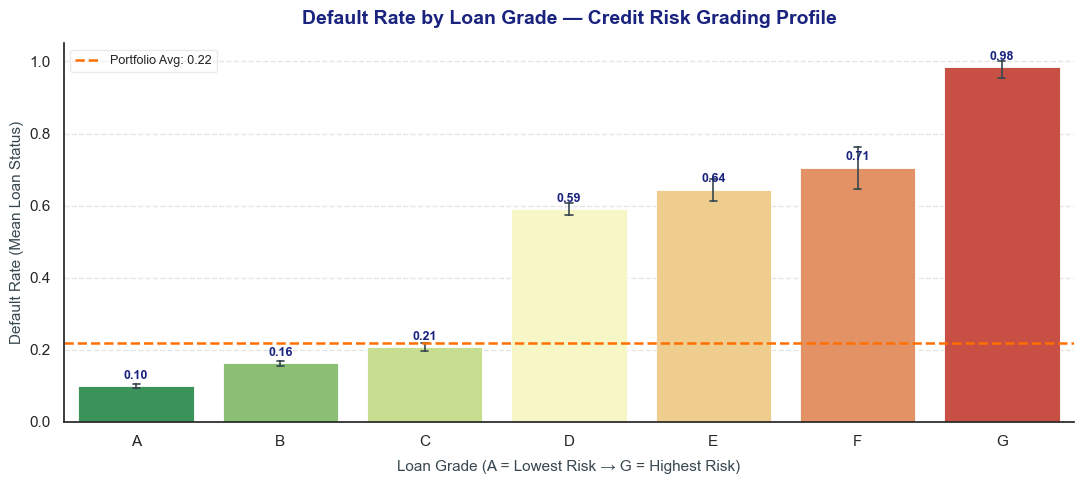

In [27]:
# DEFAULT RATE BY LOAN GRADE — Credit Risk Grading Analysis
fig, ax = plt.subplots(figsize=(11, 5))

grade_order = sorted(df["loan_grade"].dropna().unique())

sns.barplot(
    x="loan_grade",
    y="loan_status",
    data=df,
    order=grade_order,
    palette="RdYlGn_r",
    edgecolor="white",
    linewidth=0.6,
    capsize=0.05,
    err_kws={"linewidth": 1.2, "color": "#37474F"},
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9,
                 fontweight="bold", color="#1A237E", padding=3)

ax.axhline(df["loan_status"].mean(), color="#FF6F00", linestyle="--",
           linewidth=1.8, label=f"Portfolio Avg: {df['loan_status'].mean():.2f}")

ax.set_title("Default Rate by Loan Grade — Credit Risk Grading Profile",
             fontsize=14, fontweight="bold", color="#1A237E", pad=14)
ax.set_xlabel("Loan Grade (A = Lowest Risk → G = Highest Risk)",
              fontsize=11, color="#37474F", labelpad=8)
ax.set_ylabel("Default Rate (Mean Loan Status)", fontsize=11, color="#37474F")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)

ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=9, framealpha=0.4)

plt.tight_layout()
plt.savefig("default_rate_loan_grade.png", dpi=150, bbox_inches="tight")
plt.show() 

## FEATURE ENGINEERING : 

#### LOAN-TO-INCOME RATIO (LTI) — Credit Risk Feature Engineering

  LTI RATIO — FEATURE SUMMARY (Credit Risk View)
count    32581.0000
mean         0.1706
std          0.1070
min          0.0008
25%          0.0897
50%          0.1481
75%          0.2292
max          0.8300
-------------------------------------------------------
  Null Values      : 0
  Inf Values       : 0
  > 1.0 (Extreme)  : 0 borrowers

  LTI RISK BAND DISTRIBUTION:
-------------------------------------------------------
lti_risk_band
Very Low     22229
Low           9162
Moderate      1138
High            51
Very High        1


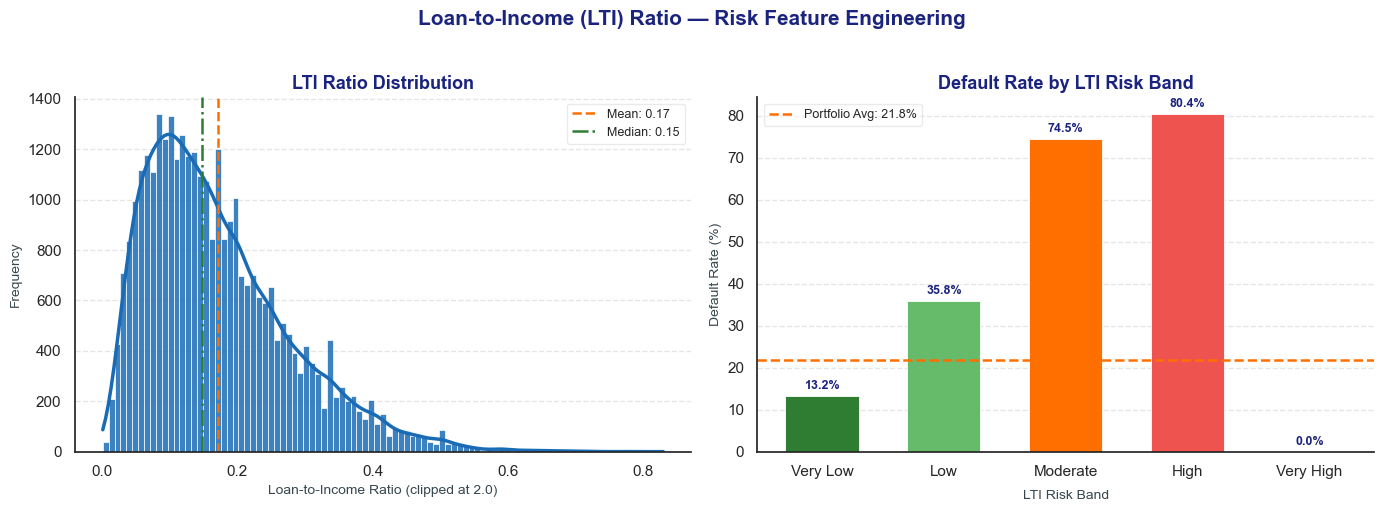

In [28]:
# LOAN-TO-INCOME RATIO (LTI) — Credit Risk Feature Engineering
df["loan_to_income_ratio"] = (
    df["loan_amnt"] / df["person_income"]
).round(4)

# Validation & Risk Bucketing
df["lti_risk_band"] = pd.cut(
    df["loan_to_income_ratio"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, float("inf")],
    labels=["Very Low", "Low", "Moderate", "High", "Very High"]
)

# Sanity Check
print("=" * 55)
print("  LTI RATIO — FEATURE SUMMARY (Credit Risk View)")
print("=" * 55)
print(df["loan_to_income_ratio"].describe().round(4).to_string())
print("-" * 55)
print(f"  Null Values      : {df['loan_to_income_ratio'].isna().sum()}")
print(f"  Inf Values       : {np.isinf(df['loan_to_income_ratio']).sum()}")
print(f"  > 1.0 (Extreme)  : {(df['loan_to_income_ratio'] > 1.0).sum()} borrowers")
print("=" * 55)
print("\n  LTI RISK BAND DISTRIBUTION:")
print("-" * 55)
print(df["lti_risk_band"].value_counts().sort_index().to_string())
print("=" * 55)

# Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — LTI Distribution
sns.histplot(
    df["loan_to_income_ratio"].clip(upper=2),
    kde=True, ax=axes[0],
    color="#1A6BB5", edgecolor="white",
    linewidth=0.5, alpha=0.85,
    line_kws={"linewidth": 2.5, "color": "#E53935"}
)
axes[0].axvline(df["loan_to_income_ratio"].mean(), color="#FF6F00",
                linestyle="--", linewidth=1.8,
                label=f"Mean: {df['loan_to_income_ratio'].mean():.2f}")
axes[0].axvline(df["loan_to_income_ratio"].median(), color="#2E7D32",
                linestyle="-.", linewidth=1.8,
                label=f"Median: {df['loan_to_income_ratio'].median():.2f}")
axes[0].set_title("LTI Ratio Distribution", fontsize=13,
                  fontweight="bold", color="#1A237E")
axes[0].set_xlabel("Loan-to-Income Ratio (clipped at 2.0)", fontsize=10, color="#37474F")
axes[0].set_ylabel("Frequency", fontsize=10, color="#37474F")
axes[0].legend(fontsize=9, framealpha=0.4)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].yaxis.grid(True, linestyle="--", alpha=0.5)
axes[0].set_axisbelow(True)

# Plot 2 — Default Rate by LTI Risk Band
band_default = df.groupby("lti_risk_band", observed=True)["loan_status"].mean().mul(100).round(2)
colors = ["#2E7D32", "#66BB6A", "#FF6F00", "#EF5350", "#B71C1C"]
bars = axes[1].bar(band_default.index, band_default.values,
                   color=colors, edgecolor="white", linewidth=0.6, width=0.6)
axes[1].bar_label(bars, fmt="%.1f%%", fontsize=9,
                  fontweight="bold", color="#1A237E", padding=3)
axes[1].axhline(df["loan_status"].mean() * 100, color="#FF6F00",
                linestyle="--", linewidth=1.8,
                label=f"Portfolio Avg: {df['loan_status'].mean()*100:.1f}%")
axes[1].set_title("Default Rate by LTI Risk Band",
                  fontsize=13, fontweight="bold", color="#1A237E")
axes[1].set_xlabel("LTI Risk Band", fontsize=10, color="#37474F", labelpad=8)
axes[1].set_ylabel("Default Rate (%)", fontsize=10, color="#37474F")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].yaxis.grid(True, linestyle="--", alpha=0.5)
axes[1].set_axisbelow(True)
axes[1].legend(fontsize=9, framealpha=0.4)

fig.suptitle("Loan-to-Income (LTI) Ratio — Risk Feature Engineering",
             fontsize=15, fontweight="bold", color="#1A237E", y=1.02)

plt.tight_layout()
plt.savefig("lti_ratio_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

#### INCOME PER YEAR EMPLOYED — Credit Stability Feature Engineering

  INCOME PER YEAR EMPLOYED — FEATURE SUMMARY
count      31686.00
mean       19505.63
std        26706.23
min          475.81
25%         6888.89
50%        11500.10
75%        21666.67
max      2039784.00
------------------------------------------------------------
  Null Values        : 895
  Inf Values         : 0
  Negative Values    : 0
  > $100K (Extreme)  : 475 borrowers

  INCOME STABILITY BAND DISTRIBUTION:
------------------------------------------------------------
income_stability_band
Very Low     13958
Low          11167
Moderate      4213
High          1873
Very High      475


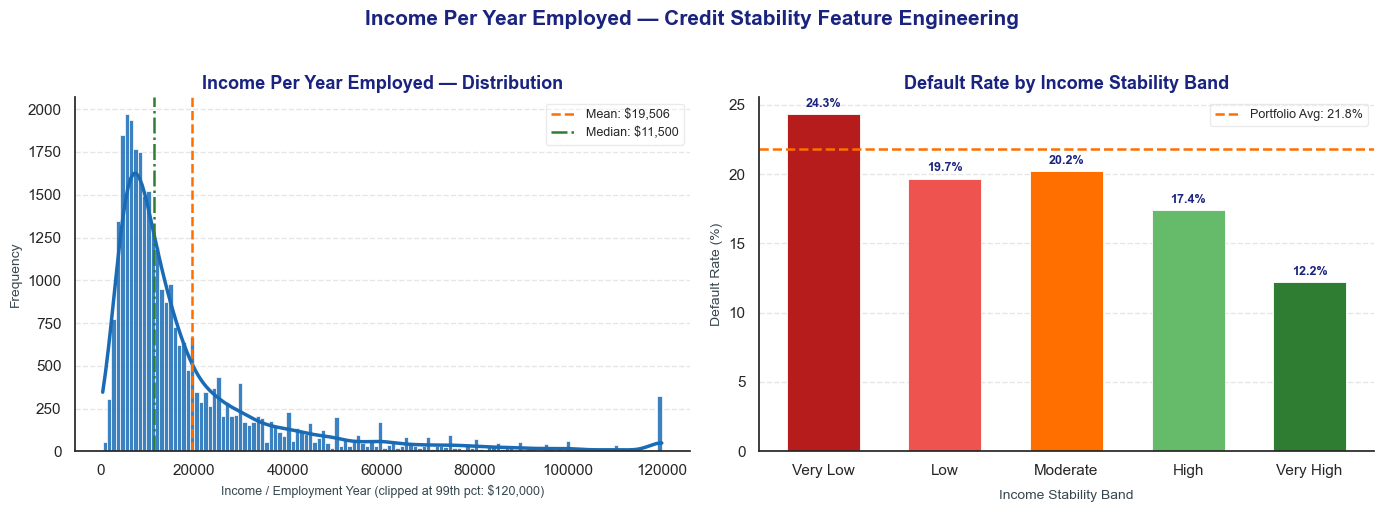

In [29]:
# INCOME PER YEAR EMPLOYED — Credit Stability Feature Engineering

df["income_per_year_employed"] = (
    df["person_income"] / (df["person_emp_length"] + 1)  # +1 avoids division by zero
).round(4)

# Risk Bucketing
df["income_stability_band"] = pd.cut(
    df["income_per_year_employed"],
    bins=[0, 10000, 25000, 50000, 100000, float("inf")],
    labels=["Very Low", "Low", "Moderate", "High", "Very High"]
)

# Sanity Check
print("=" * 60)
print("  INCOME PER YEAR EMPLOYED — FEATURE SUMMARY")
print("=" * 60)
print(df["income_per_year_employed"].describe().round(2).to_string())
print("-" * 60)
print(f"  Null Values        : {df['income_per_year_employed'].isna().sum()}")
print(f"  Inf Values         : {np.isinf(df['income_per_year_employed']).sum()}")
print(f"  Negative Values    : {(df['income_per_year_employed'] < 0).sum()}")
print(f"  > $100K (Extreme)  : {(df['income_per_year_employed'] > 100000).sum()} borrowers")
print("=" * 60)
print("\n  INCOME STABILITY BAND DISTRIBUTION:")
print("-" * 60)
print(df["income_stability_band"].value_counts().sort_index().to_string())
print("=" * 60)

# Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Distribution
clip_val = df["income_per_year_employed"].quantile(0.99)
sns.histplot(
    df["income_per_year_employed"].clip(upper=clip_val),
    kde=True, ax=axes[0],
    color="#1A6BB5", edgecolor="white",
    linewidth=0.5, alpha=0.85,
    line_kws={"linewidth": 2.5, "color": "#E53935"}
)
axes[0].axvline(df["income_per_year_employed"].mean(), color="#FF6F00",
                linestyle="--", linewidth=1.8,
                label=f"Mean: ${df['income_per_year_employed'].mean():,.0f}")
axes[0].axvline(df["income_per_year_employed"].median(), color="#2E7D32",
                linestyle="-.", linewidth=1.8,
                label=f"Median: ${df['income_per_year_employed'].median():,.0f}")
axes[0].set_title("Income Per Year Employed — Distribution",
                  fontsize=13, fontweight="bold", color="#1A237E")
axes[0].set_xlabel(f"Income / Employment Year (clipped at 99th pct: ${clip_val:,.0f})",
                   fontsize=9, color="#37474F")
axes[0].set_ylabel("Frequency", fontsize=10, color="#37474F")
axes[0].legend(fontsize=9, framealpha=0.4)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].yaxis.grid(True, linestyle="--", alpha=0.5)
axes[0].set_axisbelow(True)

# Plot 2 — Default Rate by Income Stability Band
band_default = (
    df.groupby("income_stability_band", observed=True)["loan_status"]
    .mean().mul(100).round(2)
)
colors = ["#B71C1C", "#EF5350", "#FF6F00", "#66BB6A", "#2E7D32"]
bars = axes[1].bar(band_default.index, band_default.values,
                   color=colors, edgecolor="white", linewidth=0.6, width=0.6)
axes[1].bar_label(bars, fmt="%.1f%%", fontsize=9,
                  fontweight="bold", color="#1A237E", padding=3)
axes[1].axhline(df["loan_status"].mean() * 100, color="#FF6F00",
                linestyle="--", linewidth=1.8,
                label=f"Portfolio Avg: {df['loan_status'].mean()*100:.1f}%")
axes[1].set_title("Default Rate by Income Stability Band",
                  fontsize=13, fontweight="bold", color="#1A237E")
axes[1].set_xlabel("Income Stability Band", fontsize=10, color="#37474F", labelpad=8)
axes[1].set_ylabel("Default Rate (%)", fontsize=10, color="#37474F")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].yaxis.grid(True, linestyle="--", alpha=0.5)
axes[1].set_axisbelow(True)
axes[1].legend(fontsize=9, framealpha=0.4)

fig.suptitle("Income Per Year Employed — Credit Stability Feature Engineering",
             fontsize=15, fontweight="bold", color="#1A237E", y=1.02)

plt.tight_layout()
plt.savefig("income_stability_analysis.png", dpi=150, bbox_inches="tight")
plt.show() 

#### CREDIT HISTORY AGE RATIO (CHAR)


Credit History Age Ratio Summary


count    32581.000
mean         0.188
std          0.091
min          0.014
25%          0.120
50%          0.167
75%          0.255
max          0.577
Name: credit_history_age_ratio, dtype: float64


Default Rate by Credit Maturity


credit_maturity_band
Very Thin        23.38
Thin             21.84
Average          21.86
Mature           21.02
Highly Mature    20.90
Name: loan_status, dtype: float64

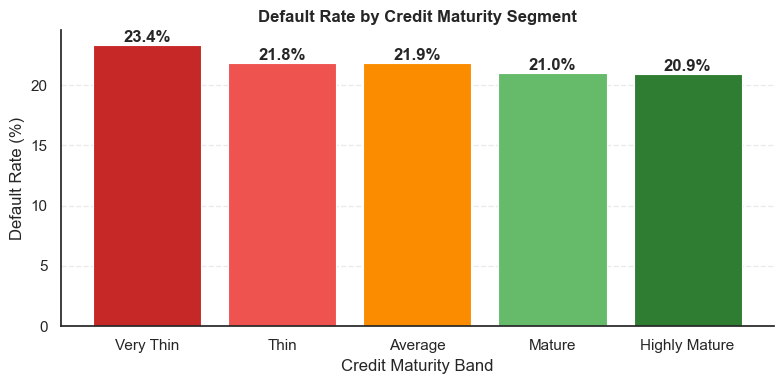

In [31]:
# CREDIT HISTORY AGE RATIO (CHAR)
# Measures financial maturity of a borrower
# Higher Ratio → Longer credit exposure relative to age
# Lower Ratio → Thin / Young credit profile 

df["credit_history_age_ratio"] = (
    df["cb_person_cred_hist_length"] /
    (df["person_age"] + 1)
).round(4)

# Credit Maturity Segmentation
df["credit_maturity_band"] = pd.qcut(
    df["credit_history_age_ratio"],
    q=5,
    labels=[
        "Very Thin",
        "Thin",
        "Average",
        "Mature",
        "Highly Mature"
    ]
)

# Portfolio Summary
print("\nCredit History Age Ratio Summary")
display(df["credit_history_age_ratio"].describe().round(3))

# Risk Validation
credit_risk_view = (
    df.groupby("credit_maturity_band", observed=True)["loan_status"]
      .mean()
      .mul(100)
      .round(2)
)

print("\nDefault Rate by Credit Maturity")
display(credit_risk_view)

# Visualization

risk_colors = [
    "#C62828",  # Very Thin (highest risk)
    "#EF5350",
    "#FB8C00",
    "#66BB6A",
    "#2E7D32"   # Highly Mature (lowest risk)
]

plt.figure(figsize=(8,4))

bars = plt.bar(
    credit_risk_view.index,
    credit_risk_view.values,
    color=risk_colors,
    edgecolor="white",
    linewidth=0.8
)

plt.title(
    "Default Rate by Credit Maturity Segment",
    fontsize=12,
    fontweight="bold"
)
plt.ylabel("Default Rate (%)")
plt.xlabel("Credit Maturity Band")

plt.bar_label(
    bars,
    fmt="%.1f%%",
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

#### HIGH-RISK LOAN GRADE FLAG


High-Risk Grade Distribution (%)


high_risk_grade
0    84.98
1    15.02
Name: proportion, dtype: float64


Default Rate by Loan Grade Category


high_risk_grade
A-C Grade    14.86
D-G Grade    61.18
Name: loan_status, dtype: float64

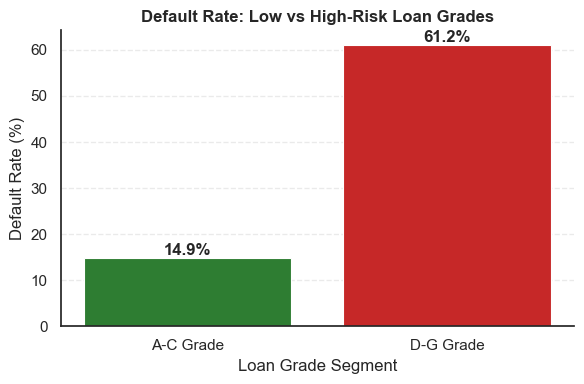


Borrowers with D-G grades show a 46.32% higher default rate than A-C grades.


In [33]:
# HIGH-RISK LOAN GRADE FLAG
# Grades D-G are generally associated with higher default risk

df["high_risk_grade"] = np.where(
    df["loan_grade"].isin(["D", "E", "F", "G"]),
    1, 0
)

# Portfolio Summary
grade_dist = (
    df["high_risk_grade"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nHigh-Risk Grade Distribution (%)")
display(grade_dist)

# Risk Validation
grade_default = (
    df.groupby("high_risk_grade")["loan_status"]
      .mean()
      .mul(100)
      .round(2)
      .rename({
          0: "A-C Grade",
          1: "D-G Grade"
      })
)

print("\nDefault Rate by Loan Grade Category")
display(grade_default)

# Visualization
risk_colors = ["#2E7D32", "#C62828"]  # Low Risk, High Risk

plt.figure(figsize=(6,4))

bars = plt.bar(
    grade_default.index,
    grade_default.values,
    color=risk_colors,
    edgecolor="white",
    linewidth=0.8
)

plt.bar_label(
    bars,
    fmt="%.1f%%",
    fontweight="bold"
)

plt.title(
    "Default Rate: Low vs High-Risk Loan Grades",
    fontsize=12,
    fontweight="bold"
)
plt.ylabel("Default Rate (%)")
plt.xlabel("Loan Grade Segment")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Business Insight
risk_gap = round(
    grade_default.iloc[1] - grade_default.iloc[0],
    2
)

print(
    f"\nBorrowers with D-G grades show a "
    f"{risk_gap:.2f}% higher default rate than A-C grades."
)

## TRAIN TEST SPLIT : 

In [34]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## PREPROCESSING PIPELINE :

In [35]:
numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X.select_dtypes(
    include="object"
).columns

In [36]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## LOGISTIC REGRESSION PD MODEL : 

In [38]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000
    ))
])

In [39]:
logistic_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'loan_to_income_ratio', 'income_per_year_employed',
       'credit_history_age_ratio', 'high_risk_grade'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=2000))])

In [40]:
pred_lr = logistic_pipeline.predict(X_test)

prob_lr = logistic_pipeline.predict_proba(X_test)[:,1]

## LOGISTIC REGRESSION MODEL EVALUATION :

In [41]:
# LOGISTIC REGRESSION — MODEL PERFORMANCE

lr_metrics = {
    "Accuracy": accuracy_score(y_test, pred_lr),
    "Precision": precision_score(y_test, pred_lr),
    "Recall": recall_score(y_test, pred_lr),
    "F1 Score": f1_score(y_test, pred_lr),
    "ROC-AUC": roc_auc_score(y_test, prob_lr)
}

metrics_df = pd.DataFrame(
    lr_metrics.items(),
    columns=["Metric", "Score"]
)

display(metrics_df.style.format({"Score": "{:.4f}"}))

,Metric,Score
0,Accuracy,0.8726
1,Precision,0.7814
2,Recall,0.5781
3,F1 Score,0.6645
4,ROC-AUC,0.8765


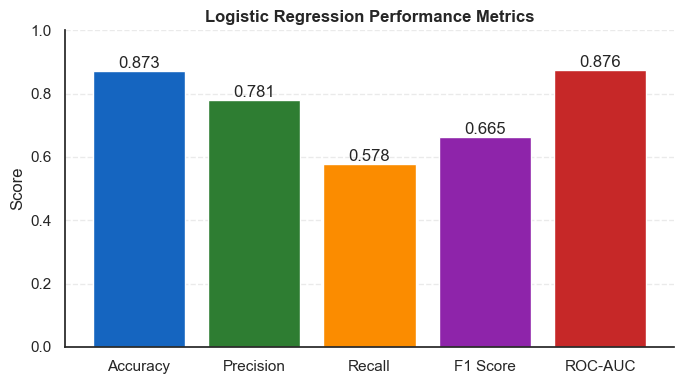

In [42]:
plt.figure(figsize=(7,4))

bars = plt.bar(
    metrics_df["Metric"],
    metrics_df["Score"],
    color=["#1565C0", "#2E7D32", "#FB8C00", "#8E24AA", "#C62828"]
)

plt.bar_label(bars, fmt="%.3f")

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title(
    "Logistic Regression Performance Metrics",
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## XG-BOOST MODEL : 

In [43]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [44]:
xgb_pipeline.fit(
    X_train,
    y_train
)

pred_xgb = xgb_pipeline.predict(X_test)

prob_xgb = xgb_pipeline.predict_proba(X_test)[:,1]

## XG-BOOST MODEL EVUALUATION 

In [45]:
# XGBOOST — CREDIT RISK MODEL PERFORMANCE

print("\nClassification Report")
print("-" * 60)
print(classification_report(y_test, pred_xgb))

# Key Metrics
xgb_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [
        accuracy_score(y_test, pred_xgb),
        precision_score(y_test, pred_xgb),
        recall_score(y_test, pred_xgb),
        f1_score(y_test, pred_xgb),
        roc_auc_score(y_test, prob_xgb)
    ]
})

display(xgb_metrics.style.format({"Score": "{:.4f}"}))

# Business Insight
print(
    f"\nModel ROC-AUC: "
    f"{roc_auc_score(y_test, prob_xgb):.4f}"
)


Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5095
           1       0.98      0.72      0.83      1422

    accuracy                           0.94      6517
   macro avg       0.95      0.86      0.90      6517
weighted avg       0.94      0.94      0.93      6517



,Metric,Score
0,Accuracy,0.9363
1,Precision,0.9791
2,Recall,0.7236
3,F1 Score,0.8322
4,ROC-AUC,0.9501



Model ROC-AUC: 0.9501


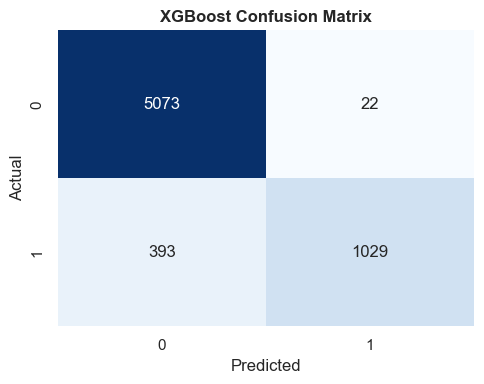

In [46]:
# Confusion Matrix

cm = confusion_matrix(y_test, pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(
    "XGBoost Confusion Matrix",
    fontweight="bold"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## ROC CURVE :

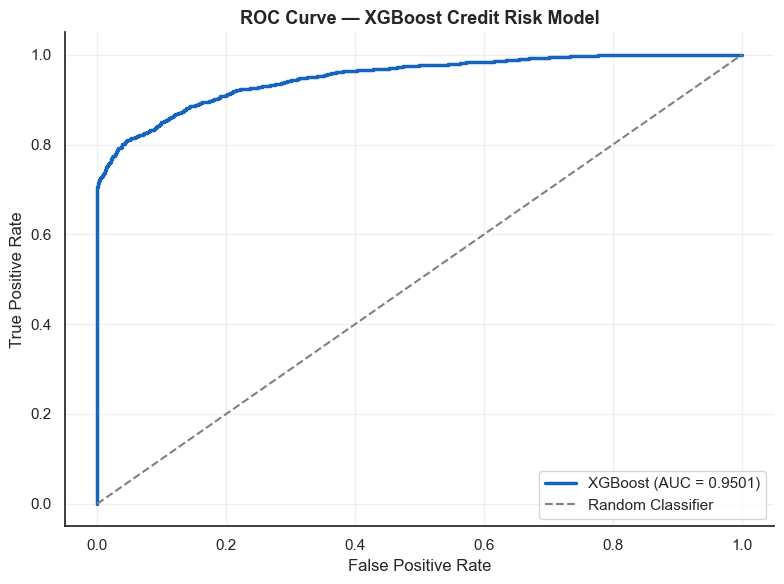


ROC-AUC Score: 0.9501
Excellent discriminatory power.


In [47]:
# XGBOOST — ROC CURVE ANALYSIS

auc_score = roc_auc_score(y_test, prob_xgb)

fpr, tpr, _ = roc_curve(
    y_test,
    prob_xgb
)

plt.figure(figsize=(8, 6))

# Model Performance Curve
plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"XGBoost (AUC = {auc_score:.4f})",
    color="#1565C0"
)

# Random Classifier Baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    color="gray",
    label="Random Classifier"
)

# Formatting
plt.title(
    "ROC Curve — XGBoost Credit Risk Model",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.gca().spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Business Interpretation
print(
    f"\nROC-AUC Score: {auc_score:.4f}"
)

if auc_score >= 0.90:
    print("Excellent discriminatory power.")
elif auc_score >= 0.80:
    print("Strong discriminatory power.")
elif auc_score >= 0.70:
    print("Acceptable discriminatory power.")
else:
    print("Weak discriminatory power.")

## SHAP - EXPLAINABILITY 

In [53]:
X_processed = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=preprocessor.get_feature_names_out()
)

In [49]:
# XG-Boost Credit Risk Classifier 

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    eval_metric="logloss"
)

xgb_model.fit(
    X_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [50]:
explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_processed
)


Top Drivers of Credit Default Risk


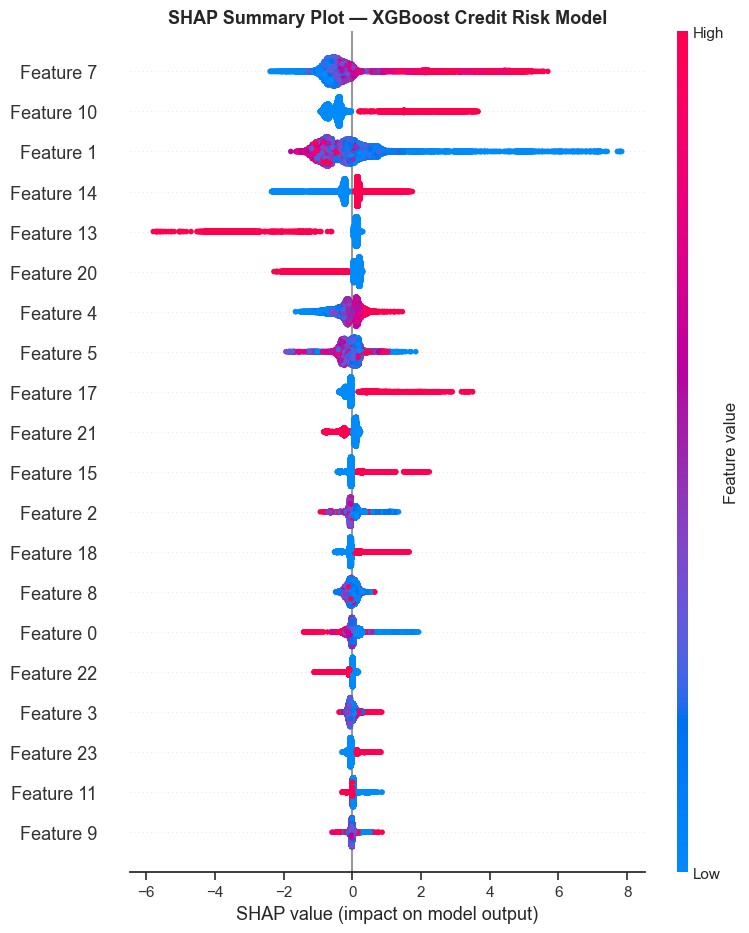

In [51]:
# SHAP ANALYSIS — FEATURE IMPACT ON DEFAULT PREDICTION

print("\nTop Drivers of Credit Default Risk")

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_processed,
    plot_type="dot",
    show=False
)

plt.title(
    "SHAP Summary Plot — XGBoost Credit Risk Model",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [54]:
# Mean Absolute SHAP Importance
shap_importance = pd.DataFrame({
    "Feature": X_processed.columns,
    "Mean_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "Mean_SHAP",
    ascending=False
)

display(shap_importance.head(10))

,Feature,Mean_SHAP
7,num__loan_to_income_ratio,0.832446
10,num__high_risk_grade,0.740760
1,num__person_income,0.662330
14,cat__person_home_ownership_RENT,0.375374
13,cat__person_home_ownership_OWN,0.374292
20,cat__loan_intent_VENTURE,0.325757
4,num__loan_int_rate,0.286225
5,num__loan_percent_income,0.198894
17,cat__loan_intent_HOMEIMPROVEMENT,0.182917
21,cat__loan_grade_A,0.164970


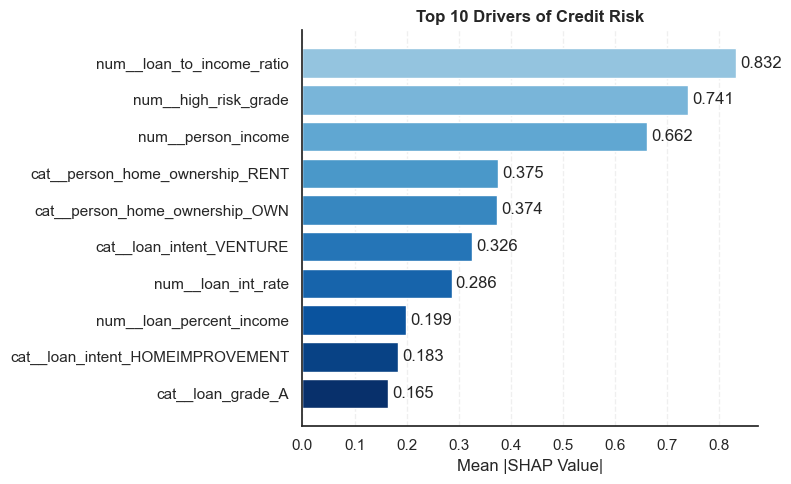

In [61]:
# Top 10 Most Influential Features

import matplotlib.cm as cm

top_features = shap_importance.head(10)

top_features = shap_importance.head(10)

colors = cm.Blues(
    np.linspace(0.4, 1, len(top_features))
)

plt.figure(figsize=(8, 5))

bars = plt.barh(
    top_features["Feature"][::-1],
    top_features["Mean_SHAP"][::-1],
    color=colors[::-1]
)

plt.bar_label(
    bars,
    fmt="%.3f",
    padding=3
)

plt.xlabel("Mean |SHAP Value|")
plt.title(
    "Top 10 Drivers of Credit Risk",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## PROBABLITY OF DEFAULT SCORES : 

In [62]:
test_data = X_test.copy()

test_data["PD"] = prob_xgb

## RISK SEGMENTATION : 

In [64]:
# PD-Based Risk Segmentation
test_data["Risk_Band"] = pd.cut(
    test_data["PD"],
    bins=[0, 0.05, 0.15, 0.30, 0.50, 1],
    labels=[
        "Very Low Risk",
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ]
)

test_data[["PD", "Risk_Band"]].head()

,PD,Risk_Band
6616,0.055179,Low Risk
21802,0.023804,Very Low Risk
31886,0.047011,Very Low Risk
17799,0.041290,Very Low Risk
5207,0.002948,Very Low Risk


## PORTFOLIO RISK DASHBOARD : 

In [66]:
## PORTFOLIO DISTRIBUTION % 

risk_summary["Portfolio_%"] = (
    risk_summary["Borrowers"]
    / risk_summary["Borrowers"].sum()
    * 100
).round(2)

display(risk_summary)

,Borrowers,Avg_PD,Min_PD,Max_PD,Portfolio_%
Risk_Band,,,,,
Very Low Risk,2877,0.0196,0.0001,0.0500,44.15
Low Risk,1862,0.0889,0.0500,0.1500,28.57
Moderate Risk,568,0.2030,0.1500,0.2995,8.72
High Risk,159,0.3747,0.3013,0.4980,2.44
Very High Risk,1051,0.9517,0.5026,0.9997,16.13


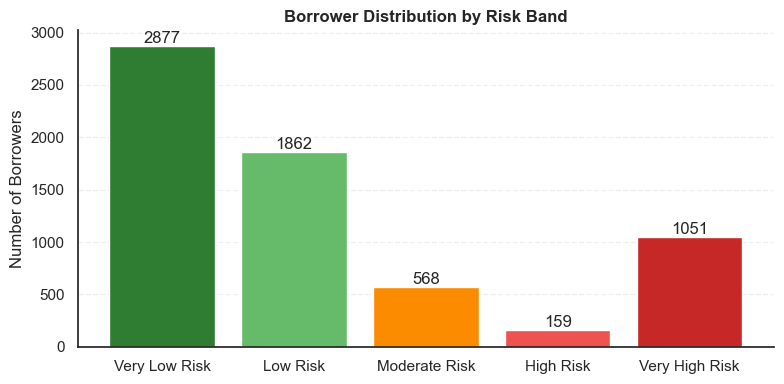

In [67]:
# VISUALS :

risk_colors = [
    "#2E7D32",  # Very Low
    "#66BB6A",
    "#FB8C00",
    "#EF5350",
    "#C62828"   # Very High
]

plt.figure(figsize=(8,4))

bars = plt.bar(
    risk_summary.index,
    risk_summary["Borrowers"],
    color=risk_colors[:len(risk_summary)]
)

plt.bar_label(bars)

plt.title(
    "Borrower Distribution by Risk Band",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel("Number of Borrowers")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [69]:
# Concentration : 

highest_risk = risk_summary["Avg_PD"].idxmax()

print(
    f"\nHighest portfolio risk concentration: "
    f"{highest_risk}"
)


Highest portfolio risk concentration: Very High Risk


# Conclusion

This project successfully developed an end-to-end Credit Risk Assessment framework for estimating the Probability of Default (PD) of loan applicants using machine learning techniques. Through comprehensive exploratory data analysis, feature engineering, data preprocessing, and predictive modeling, meaningful patterns associated with borrower default behavior were identified and utilized to assess credit risk.

Two modeling approaches, Logistic Regression and XGBoost, were implemented and evaluated to compare predictive performance and interpretability. While Logistic Regression provided a transparent baseline suitable for traditional credit scoring applications, XGBoost demonstrated superior capability in capturing complex relationships among borrower, loan, and credit history characteristics.

The analysis revealed that factors such as loan-to-income ratio, interest rate, loan grade, prior default history, and credit history length significantly influence default risk. SHAP-based explainability further enhanced model transparency by quantifying the contribution of individual features to prediction outcomes, supporting more informed and explainable lending decisions.

To improve practical applicability, borrowers were segmented into Low, Medium, and High Risk categories based on predicted Probability of Default scores. This risk segmentation framework can assist financial institutions in loan approval decisions, risk-based pricing strategies, portfolio monitoring, and capital allocation processes.

Overall, the project demonstrates how machine learning and explainable AI can be integrated into modern credit risk management systems to improve risk assessment accuracy, support data-driven lending decisions, and strengthen portfolio quality. The developed framework provides a scalable foundation that can be further extended through Expected Loss (EL), Loss Given Default (LGD), Exposure at Default (EAD), stress testing, and real-time deployment for enterprise-level credit risk applications.
